# Mode Transition State Management

Every time an agent switches modes, it faces a deceptively hard question: **what survives the switch?**

A mode switch is not a clean restart. The user's goal, the steps already taken, and the decisions already made are all still relevant - but the rules, risk thresholds, and tool permissions that belonged to the previous mode are not. Carrying the wrong state forward causes the new mode to behave incorrectly. Discarding the right state breaks coherence and forces the agent to repeat work.

Mode transition state management is the deliberate practice of deciding - for every category of state the agent holds - whether to preserve it, transform it, or discard it when the mode changes. Done poorly, it produces agents that accumulate permissions they should not have, re-litigate settled decisions, or start new modes completely blind to what has already been accomplished. Done well, mode transitions are seamless: the new mode picks up exactly where the previous one left off, operating under its own rules, without losing the thread of the task.

This notebook builds that logic incrementally: a taxonomy of agent state, rules for conversation history and working memory, a handoff message generator, a single transition function that ties it all together, and a LangGraph agent that demonstrates a full three-phase workflow.

## Setup and dependencies

We need LangChain for messages and LLM access, LangGraph for the stateful graph, standard library modules for timestamps and deep copies, and `dataclasses` to model structured working memory. All API keys are loaded from a `.env` file — never hardcoded.

In [1]:
import os
import json
import copy
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Optional, TypedDict, Sequence, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import Image, display

### Initializing the LLMs

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=os.getenv("OPENAI_API_KEY", "").strip(), temperature=0.3)
print("LLM initialised:", llm.model_name)

LLM initialised: gpt-4o-mini


We use `temperature=0.3` - low enough to keep responses consistent, but with enough variation that handoff messages and mode responses don't sound robotic.

## What constitutes agent state?
Before deciding what to preserve, we need to know what *is* the state. An agent in any active mode maintains several distinct categories of information, and each category has a different carry-forward policy.

| State category | Examples | On mode switch |
|---|---|---|
| **Conversation history** | Prior user/agent messages | Usually preserve |
| **Task context** | Goal, constraints, deliverables | Always preserve |
| **Tool state** | Cached results, in-progress calls | Depends on relevance |
| **Mode-specific constraints** | Escalation rules, risk thresholds | Always replace |
| **Working memory** | Intermediate results, notes, drafts | Selectively preserve |
| **Session metadata** | User ID, session start, mode history | Always preserve |
| **Credentials/permissions** | Tool access tokens | Always reconfigure |

The rows that say "Usually preserve" or "Selectively preserve" still require judgment - the sections below explain when the exceptions apply. The rows that say "Always replace" or "Always reconfigure" are never carried across; the new mode always defines them from scratch.

## Mode registry
We define three modes used throughout this notebook. In a real system these would be loaded from configuration - keeping them here as plain dicts makes the code self-contained and easy to follow.

Notice that each mode has its own tool access list. These are not additive - when the agent switches modes, the tool set is **replaced entirely**, not accumulated. The anti-patterns section shows what goes wrong when you accumulate instead.

In [3]:
MODE_PROMPTS: dict[str, str] = {
    "chat": (
        "You are a friendly general-purpose assistant. "
        "Keep responses warm, concise, and jargon-free."
    ),
    "research": (
        "You are a rigorous research assistant. "
        "Provide detailed, structured analyses with explicit reasoning. "
        "Use headings and bullet points."
    ),
    "planning": (
        "You are a precise planning agent. "
        "Break every goal into numbered, actionable steps. "
        "Estimate effort for each step. Be brief and specific."
    ),
}

# Which modes have write-access to tools (illustrates per-mode permissions)
MODE_TOOL_ACCESS: dict[str, list[str]] = {
    "chat":     ["web_search"],
    "research": ["web_search", "read_file", "summarise"],
    "planning": ["write_file", "create_ticket", "schedule"],
}

print("Modes defined:", list(MODE_PROMPTS.keys()))
print("Tool access per mode:")
for mode, tools in MODE_TOOL_ACCESS.items():
    print(f"  {mode}: {tools}")

Modes defined: ['chat', 'research', 'planning']
Tool access per mode:
  chat: ['web_search']
  research: ['web_search', 'read_file', 'summarise']
  planning: ['write_file', 'create_ticket', 'schedule']


The print output makes the per-mode tool boundaries explicit. Planning mode gets write tools. Research mode gets read tools. Chat mode gets only search. No overlap, no accumulation.

## Preserving or clearing conversation history
Conversation history is the most obvious candidate for preservation - but it is also the most dangerous to get wrong. Carrying it when we should clear it floods the new mode with irrelevant context. Clearing it when we should preserve it forces the new mode to reconstruct information the user already provided.

The decision comes down to **why** the mode switch is happening. A transition from research to planning on the same task should carry full history - the planning mode needs to see the research output. A transition triggered by a completely new, unrelated request should not - the new mode has no use for the previous task's dialogue. A transition across a security boundary must never carry history - the new mode should have zero knowledge of the prior session.

The function below encodes these rules explicitly, making the policy auditable and independently testable.

In [4]:
# Task-phase transitions: these always run on the same underlying goal
PHASE_TRANSITIONS: set[tuple[str, str]] = {
    ("chat",     "research"),
    ("research", "planning"),
    ("planning", "critic"),
    ("chat",     "planning"),
}


def decide_context_preservation(
    from_mode: str,
    to_mode: str,
    transition_reason: str,
) -> bool:
    """Decide whether to preserve conversation history on a mode switch.

    Args:
        from_mode: The mode being exited.
        to_mode: The mode being entered.
        transition_reason: Why the switch is happening.

    Returns:
        True to preserve history, False to clear it.
    """
    # Always preserve on task-phase transitions — same goal, different phase
    if (from_mode, to_mode) in PHASE_TRANSITIONS:
        return True

    # Risk escalation: preserve so the human reviewer has full context
    if transition_reason == "risk_escalation":
        return True

    # A new, unrelated task: fresh slate for the new mode
    if transition_reason == "new_task":
        return False

    # Security boundary crossing: never carry context across
    if transition_reason == "security_boundary":
        return False

    # Default: preserve — losing context is worse than carrying a little extra
    return True


# Show the decision for common transitions
transitions_to_check = [
    ("chat",     "research", "task_continuation"),
    ("research", "planning", "task_continuation"),
    ("chat",     "research", "risk_escalation"),
    ("planning", "chat",     "new_task"),
    ("research", "planning", "security_boundary"),
    ("chat",     "planning", "user_request"),
]

print(f"{'From':<12} {'To':<12} {'Reason':<22} {'Preserve?':<10}")
print("-" * 60)
for from_m, to_m, reason in transitions_to_check:
    preserve = decide_context_preservation(from_m, to_m, reason)
    print(f"{from_m:<12} {to_m:<12} {reason:<22} {'YES' if preserve else 'NO'}")

From         To           Reason                 Preserve? 
------------------------------------------------------------
chat         research     task_continuation      YES
research     planning     task_continuation      YES
chat         research     risk_escalation        YES
planning     chat         new_task               NO
research     planning     security_boundary      YES
chat         planning     user_request           YES


The output table makes the policy machine-readable. In a production system we would load these rules from configuration, not hardcode them - but the structure stays the same. Encoding the decision as a standalone function (not buried in a class) means we can unit-test it against specific transition scenarios without involving the LLM.

## Working memory pruning
Conversation history is coarse - it is the full dialogue. Working memory is finer-grained: it holds the agent's intermediate results, cached search output, drafted content, and risk scores. These items have very different carry-forward policies and need to be handled individually rather than preserved or discarded as a block.

The `WorkingMemory` dataclass below names each field explicitly. This forces the transition logic to make a deliberate choice about each one rather than blindly copying the whole object.

In [5]:
@dataclass
class WorkingMemory:
    """Agent working memory during task execution.

    Attributes:
        task_goal: The user's stated goal (always carry).
        completed_steps: Steps already finished (always carry — don't redo work).
        current_draft: In-progress output like a document or plan (carry if task continues).
        search_cache: Cached web/document search results (clear — may be stale or mode-inappropriate).
        risk_scores: Risk assessments from current mode (clear — new mode has its own framework).
        human_decisions: Explicit human approvals or rejections (always carry).
        tool_results: Results from tool calls (selectively carry).
    """
    task_goal: str = ""
    completed_steps: list = field(default_factory=list)
    current_draft: str = ""
    search_cache: dict = field(default_factory=dict)
    risk_scores: dict = field(default_factory=dict)
    human_decisions: list = field(default_factory=list)
    tool_results: dict = field(default_factory=dict)


# Mode-relevance map: which tool-result types are meaningful in each mode
MODE_RELEVANT_TOOLS: dict[str, set[str]] = {
    "research": {"web_search", "summarise", "read_file"},
    "planning":  {"read_file", "create_ticket", "schedule"},
    "chat":      set(),
}


def _is_relevant_to_new_mode(tool_name: str, to_mode: str) -> bool:
    """Check whether a tool result is relevant in the target mode."""
    return tool_name in MODE_RELEVANT_TOOLS.get(to_mode, set())


def transition_working_memory(
    memory: WorkingMemory,
    from_mode: str,
    to_mode: str,
) -> WorkingMemory:
    """Prune and prepare working memory for a mode transition.

    Fields that are always carried: task_goal, completed_steps, human_decisions.
    Fields that are always cleared: search_cache, risk_scores.
    Fields that are selectively carried: current_draft, tool_results.

    Args:
        memory: The working memory of the outgoing mode.
        from_mode: The mode being exited.
        to_mode: The mode being entered.

    Returns:
        A new WorkingMemory with the appropriate fields set.
    """
    # Carry draft only when the new mode continues work on the same output
    carry_draft = (from_mode, to_mode) in PHASE_TRANSITIONS

    # Carry only tool results that are relevant to the new mode
    relevant_tool_results = {
        k: v for k, v in memory.tool_results.items()
        if _is_relevant_to_new_mode(k, to_mode)
    }

    return WorkingMemory(
        task_goal=memory.task_goal,                          # Always carry
        completed_steps=copy.copy(memory.completed_steps),  # Always carry
        human_decisions=copy.copy(memory.human_decisions),  # Always carry
        current_draft=memory.current_draft if carry_draft else "",
        search_cache={},                                     # Always clear
        risk_scores={},                                      # Always clear
        tool_results=relevant_tool_results,
    )


# Demonstrate: simulate a research-mode working memory transitioning to planning
research_memory = WorkingMemory(
    task_goal="Build a production RAG pipeline for customer support",
    completed_steps=[
        "Reviewed 5 RAG papers",
        "Compared Pinecone vs Qdrant vs Weaviate",
        "Identified Qdrant as preferred vector store",
    ],
    current_draft="## RAG Architecture Options\n\n1. Qdrant + LangChain...",
    search_cache={"qdrant vs pinecone": "Qdrant has better self-hosted support..."},
    risk_scores={"data_privacy": 0.7, "latency": 0.4},
    human_decisions=["Approved: use Qdrant", "Approved: self-hosted deployment"],
    tool_results={
        "web_search": {"qdrant": "open-source, Rust-based..."},
        "read_file":  {"requirements.txt": "langchain>=0.2..."},
        "summarise":  {"paper1": "RAPTOR achieves..."},
    },
)

planning_memory = transition_working_memory(research_memory, "research", "planning")

print("WORKING MEMORY TRANSITION: research → planning")
print("=" * 55)
print(f"  task_goal        : {'CARRIED  ✓' if planning_memory.task_goal else 'CLEARED'}")
print(f"  completed_steps  : {'CARRIED  ✓' if planning_memory.completed_steps else 'CLEARED'} ({len(planning_memory.completed_steps)} steps)")
print(f"  human_decisions  : {'CARRIED  ✓' if planning_memory.human_decisions else 'CLEARED'} ({len(planning_memory.human_decisions)} decisions)")
print(f"  current_draft    : {'CARRIED  ✓' if planning_memory.current_draft else 'CLEARED  ✗'} (phase transition)")
print(f"  search_cache     : {'CLEARED  ✗' if not planning_memory.search_cache else 'CARRIED'}")
print(f"  risk_scores      : {'CLEARED  ✗' if not planning_memory.risk_scores else 'CARRIED'}")
print(f"  tool_results     : {list(planning_memory.tool_results.keys())} (only planning-relevant)")
print()
print(f"Carried task goal   : {planning_memory.task_goal}")
print(f"Carried human decisions: {planning_memory.human_decisions}")

WORKING MEMORY TRANSITION: research → planning
  task_goal        : CARRIED  ✓
  completed_steps  : CARRIED  ✓ (3 steps)
  human_decisions  : CARRIED  ✓ (2 decisions)
  current_draft    : CARRIED  ✓ (phase transition)
  search_cache     : CLEARED  ✗
  risk_scores      : CLEARED  ✗
  tool_results     : ['read_file'] (only planning-relevant)

Carried task goal   : Build a production RAG pipeline for customer support
Carried human decisions: ['Approved: use Qdrant', 'Approved: self-hosted deployment']


The key insight is that **clearing is not the same as losing**. The search cache is cleared because its results are stale and mode-inappropriate for the planning agent - but the *conclusions* from that research are preserved in `completed_steps` and `current_draft`. Risk scores are cleared because planning mode defines its own risk framework - but the human decisions (which encode the outcomes of risk deliberation) are always carried forward.

## In-progress operation handling and the transition function
What if the agent is mid-tool-call when a mode switch is requested? Abandoning an operation silently can leave external state - a file, a database row, a ticket - inconsistent. Three strategies apply:

| Strategy | When to use |
|---|---|
| **Complete then switch** | Operation is fast and safe to finish |
| **Cancel then switch** | Operation is risky, destructive, or too long to wait |
| **Pause → switch → resume** | Operation is long-running and the switch is temporary |

In practice, the calling code resolves any pending operation before handing control to the transition function. The transition function itself does not manage in-progress operations - it receives a clean working memory, either with or without the results of the completed or cancelled operation.

With all three decisions defined — context preservation, working memory pruning, and in-progress operation handling - we can consolidate them into a single `transition_mode()` function. A plain function is sufficient here: there is no statefulness needed, only a set of decisions applied in sequence.

In [6]:
def get_current_timestamp() -> str:
    """Return the current UTC time as an ISO 8601 string."""
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def transition_mode(
    from_mode: str,
    to_mode: str,
    reason: str,
    working_memory: WorkingMemory,
    conversation_history: list,
    session_id: str = "session-001",
) -> dict:
    """Execute a safe mode transition.

    Combines context preservation, memory pruning, and audit logging into a single composable function. Returns a preserved state package and a structured audit entry.

    Args:
        from_mode: The mode being exited.
        to_mode: The mode being entered.
        reason: Why the switch is happening.
        working_memory: The current working memory.
        conversation_history: The current conversation messages.
        session_id: Session identifier for audit logging.

    Returns:
        A dict with 'preserved_state' and 'audit_entry'.
    """
    # Decide what conversation history to carry forward
    preserve_history = decide_context_preservation(from_mode, to_mode, reason)
    carried_history = conversation_history if preserve_history else []

    # Prune working memory for the new mode
    new_memory = transition_working_memory(working_memory, from_mode, to_mode)

    # Assemble the preserved state package for the new mode
    preserved_state = {
        "conversation_history": carried_history,
        "task_goal": new_memory.task_goal,
        "completed_steps": new_memory.completed_steps,
        "human_decisions": new_memory.human_decisions,
        "current_draft": new_memory.current_draft,
        "tool_results": new_memory.tool_results,
    }

    # Build the audit entry — metadata only, no raw content
    audit_entry = {
        "event": "mode_transition",
        "session_id": session_id,
        "timestamp": get_current_timestamp(),
        "from_mode": from_mode,
        "to_mode": to_mode,
        "reason": reason,
        "history_preserved": preserve_history,
        "steps_carried": len(new_memory.completed_steps),
        "decisions_carried": len(new_memory.human_decisions),
        "draft_carried": bool(new_memory.current_draft),
    }

    return {"preserved_state": preserved_state, "audit_entry": audit_entry}


# --- Demonstrate the transition function ---
sample_memory = WorkingMemory(
    task_goal="Build a production RAG pipeline for customer support",
    completed_steps=["Reviewed RAG papers", "Selected Qdrant"],
    human_decisions=["Approved: use Qdrant (self-hosted)"],
)
sample_history = [
    HumanMessage(content="Research the best RAG options."),
    AIMessage(content="I have reviewed 5 approaches. Qdrant is recommended."),
]

result = transition_mode(
    from_mode="research",
    to_mode="planning",
    reason="task_continuation",
    working_memory=sample_memory,
    conversation_history=sample_history,
)

print("TRANSITION RESULT: research → planning")
print("=" * 50)
print(f"History preserved  : {result['audit_entry']['history_preserved']}")
print(f"Steps carried      : {result['audit_entry']['steps_carried']}")
print(f"Decisions carried  : {result['audit_entry']['decisions_carried']}")
print(f"Draft carried      : {result['audit_entry']['draft_carried']}")
print()
print("AUDIT ENTRY:")
print(json.dumps(result['audit_entry'], indent=2))

TRANSITION RESULT: research → planning
History preserved  : True
Steps carried      : 2
Decisions carried  : 1
Draft carried      : False

AUDIT ENTRY:
{
  "event": "mode_transition",
  "session_id": "session-001",
  "timestamp": "2026-06-05T19:15:51+00:00",
  "from_mode": "research",
  "to_mode": "planning",
  "reason": "task_continuation",
  "history_preserved": true,
  "steps_carried": 2,
  "decisions_carried": 1,
  "draft_carried": false
}


The transition function is clean and composable: call it, get back a preserved state package and an audit entry, then decide what to do with both. The LangGraph nodes in the next section call this function directly.

## Handoff messages
The new mode cannot read the outgoing mode's mind. A **handoff message** is a structured briefing injected into the new mode's context at the start of its first turn. It answers the three questions the incoming mode needs immediately: what is the task goal, what has already been done, and what decisions have been made that should not be re-litigated.

The handoff is injected as a `HumanMessage` - not as a system prompt. This is intentional: the LLM treats it as established user context rather than permanent instructions, which means it remains in the conversation history and the model can reason about it naturally. Injecting as a system prompt risks it being overridden by later system messages.

In [7]:
def generate_mode_handoff_message(
    from_mode: str,
    to_mode: str,
    preserved_state: dict,
) -> str:
    """Generate a structured briefing message for the incoming mode.

    Args:
        from_mode: The mode being exited.
        to_mode: The mode being entered.
        preserved_state: The state package produced by ModeTransitionManager.transition().

    Returns:
        A formatted string to inject as the first message in the new mode.
    """
    completed = preserved_state.get("completed_steps", [])
    goal = preserved_state.get("task_goal", "unknown goal")
    decisions = preserved_state.get("human_decisions", [])
    draft_preview = preserved_state.get("current_draft", "")

    steps_text = (
        "\n".join(f"  - {step}" for step in completed)
        if completed else "  None yet."
    )
    decisions_text = (
        "\n".join(f"  - {d}" for d in decisions)
        if decisions else "  None."
    )
    draft_text = (
        f"\nIN-PROGRESS DRAFT:\n  {draft_preview[:300]}{'...' if len(draft_preview) > 300 else ''}"
        if draft_preview else ""
    )

    return (
        f"[MODE TRANSITION: {from_mode.upper()} → {to_mode.upper()}]\n"
        f"\nCONTINUING TASK: {goal}\n"
        f"\nWHAT HAS BEEN DONE:\n{steps_text}\n"
        f"\nHUMAN DECISIONS MADE:\n{decisions_text}"
        f"{draft_text}\n"
        f"\nYOU ARE NOW IN {to_mode.upper()} MODE.\n"
        f"Apply all {to_mode} mode constraints to this continuing task.\n"
        f"Do not repeat completed steps. Build on the existing progress.\n"
        f"[END OF HANDOFF]"
    )


# Build an example preserved state and generate its handoff message
example_state = {
    "task_goal": "Build a production RAG pipeline for customer support",
    "completed_steps": [
        "Reviewed 5 RAG architecture papers",
        "Compared Pinecone vs Qdrant vs Weaviate",
        "Identified Qdrant as the preferred vector store",
        "Drafted high-level architecture diagram",
    ],
    "human_decisions": [
        "Approved: use Qdrant (self-hosted)",
        "Approved: LangChain as orchestration layer",
    ],
    "current_draft": "## RAG Architecture Options\n\n1. Qdrant (recommended)\n2. Weaviate (fallback)\n",
}

handoff_msg = generate_mode_handoff_message("research", "planning", example_state)
print(handoff_msg)

[MODE TRANSITION: RESEARCH → PLANNING]

CONTINUING TASK: Build a production RAG pipeline for customer support

WHAT HAS BEEN DONE:
  - Reviewed 5 RAG architecture papers
  - Compared Pinecone vs Qdrant vs Weaviate
  - Identified Qdrant as the preferred vector store
  - Drafted high-level architecture diagram

HUMAN DECISIONS MADE:
  - Approved: use Qdrant (self-hosted)
  - Approved: LangChain as orchestration layer
IN-PROGRESS DRAFT:
  ## RAG Architecture Options

1. Qdrant (recommended)
2. Weaviate (fallback)


YOU ARE NOW IN PLANNING MODE.
Apply all planning mode constraints to this continuing task.
Do not repeat completed steps. Build on the existing progress.
[END OF HANDOFF]


The handoff message is explicit about what is settled and what is not. The planning agent will not relitigate the vector store choice or re-read the research papers - it will start from where the research agent left off.

Now let's see what happens when we inject this handoff message into the planning mode's first LLM call.

In [8]:
# Inject the handoff message and run the planning-mode agent
messages = [
    SystemMessage(content=MODE_PROMPTS["planning"]),
    HumanMessage(content=handoff_msg),
    HumanMessage(content="Now create a 2-week implementation plan for the RAG pipeline."),
]

response = llm.invoke(messages)
print("PLANNING AGENT RESPONSE (post-transition from research mode)")
print("=" * 60)
print(response.content)

PLANNING AGENT RESPONSE (post-transition from research mode)
### 2-Week Implementation Plan for RAG Pipeline

#### Week 1

1. **Set Up Qdrant Environment**  
   - **Action**: Install Qdrant on the server.  
   - **Effort**: 2 days  
   - **Details**: Follow official documentation for installation and configuration.

2. **Configure Qdrant for Data Ingestion**  
   - **Action**: Define data schema and configure ingestion pipelines.  
   - **Effort**: 1 day  
   - **Details**: Determine data types and structures for customer support queries.

3. **Integrate LangChain with Qdrant**  
   - **Action**: Set up LangChain to communicate with Qdrant.  
   - **Effort**: 2 days  
   - **Details**: Implement necessary API calls and test basic interactions.

4. **Develop Data Preprocessing Scripts**  
   - **Action**: Create scripts for cleaning and formatting customer support data.  
   - **Effort**: 1 day  
   - **Details**: Ensure data is ready for ingestion into Qdrant.

5. **Ingest Initial Data

The handoff message is explicit about what is settled and what is not. The planning agent will not relitigate the vector store choice or re-read the research papers - it picks up from where the research agent left off.

## LangGraph agent with state-aware transitions
The individual functions above are useful on their own, but the real value comes from wiring them into a stateful graph. LangGraph threads the full agent state through every node, so each processing step has access to the complete session context - including mode, task goal, working memory, and the transition audit log.

Our graph has two nodes: **`respond_node`** runs the LLM in the current mode, and **`transition_node`** calls `transition_mode()`, generates the handoff message, and switches to the next mode. A conditional edge routes between them based on whether there is a next phase to enter.

The state definition below uses `add_messages` on the `messages` field so LangGraph automatically accumulates messages across nodes rather than replacing them.

In [9]:
class AgentState(TypedDict):
    """LangGraph state for a mode-switching agent.

    Attributes:
        messages: Full conversation history (auto-accumulated by LangGraph).
        current_mode: The mode currently active.
        mode_history: Ordered list of all modes visited in this session.
        task_goal: The user's stated goal (persists across all modes).
        completed_steps: Steps finished by any mode so far.
        human_decisions: Human approvals made during the session.
        current_draft: In-progress output being built across modes.
        transition_log: Audit trail of all mode transitions.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    current_mode: str
    mode_history: list
    task_goal: str
    completed_steps: list
    human_decisions: list
    current_draft: str
    transition_log: list


# The planned transition sequence for this demo workflow
TRANSITION_SEQUENCE = ["chat", "research", "planning"]

print("AgentState fields defined:")
for field_name in AgentState.__annotations__:
    print(f"  - {field_name}")

AgentState fields defined:
  - messages
  - current_mode
  - mode_history
  - task_goal
  - completed_steps
  - human_decisions
  - current_draft
  - transition_log


The state is richer than a standard LangGraph state because mode transitions require mode metadata, working memory fields, and the transition log to be threaded through every step.

The graph uses two nodes:

- **`transition_node`** - calls `transition_mode()`, generates the handoff message, injects it as the first message in the new mode's context, and updates the current mode and transition log.
- **`respond_node`** - applies the mode system prompt, calls the LLM, and captures any state updates from the response.

This two-node design keeps each responsibility clean. The transition logic lives entirely in `transition_node`. The LLM reasoning lives entirely in `respond_node`. Neither node does both.

In [10]:
def transition_node(state: AgentState) -> dict:
    """Node: execute the mode transition and inject the handoff message.

    Determines the next mode in the sequence, calls transition_mode() to decide what state to preserve, generates the handoff message, and injects it as the first message in the new mode's context.
    """
    from_mode = state["current_mode"]
    current_idx = TRANSITION_SEQUENCE.index(from_mode)
    to_mode = TRANSITION_SEQUENCE[current_idx + 1]

    # Build working memory from the current graph state fields
    working_memory = WorkingMemory(
        task_goal=state["task_goal"],
        completed_steps=state["completed_steps"],
        human_decisions=state["human_decisions"],
        current_draft=state["current_draft"],
    )

    # Run the full transition: preserve history, prune memory, build audit entry
    result = transition_mode(
        from_mode=from_mode,
        to_mode=to_mode,
        reason="task_continuation",
        working_memory=working_memory,
        conversation_history=list(state["messages"]),
    )

    preserved = result["preserved_state"]
    audit = result["audit_entry"]

    # Generate and inject the handoff message into the new mode's context
    handoff = generate_mode_handoff_message(from_mode, to_mode, preserved)

    print(f"  [transition] {from_mode.upper()} → {to_mode.upper()}")
    print(f"    History preserved : {audit['history_preserved']}")
    print(f"    Steps carried     : {audit['steps_carried']}")
    print(f"    Draft carried     : {audit['draft_carried']}")

    return {
        "current_mode": to_mode,
        "mode_history": state["mode_history"] + [to_mode],
        "completed_steps": preserved["completed_steps"],
        "human_decisions": preserved["human_decisions"],
        "current_draft": preserved["current_draft"],
        "transition_log": state["transition_log"] + [audit],
        # Inject the handoff as the first message in the new mode's conversation
        "messages": [HumanMessage(content=handoff)],
    }


def respond_node(state: AgentState) -> dict:
    """Node: run the LLM in the current mode and capture the response.

    Applies the mode system prompt, calls the LLM, and extracts any state updates signalled in the response.
    """
    current_mode = state["current_mode"]
    system_prompt = MODE_PROMPTS[current_mode]

    # Prepend the mode system prompt — replaced each call, never accumulated
    full_messages = [SystemMessage(content=system_prompt)] + list(state["messages"])
    response = llm.invoke(full_messages)

    print(f"  [respond] Mode: {current_mode.upper()}")
    print(f"    Response preview: {response.content[:150]}...")

    # Heuristic: extract steps the LLM marks as completed in its response
    new_steps = [
        line.strip().lstrip("✓- ").strip()
        for line in response.content.splitlines()
        if line.strip().startswith(("✓", "- Completed", "Completed:"))
    ]
    updated_steps = (
        state["completed_steps"] + new_steps if new_steps else state["completed_steps"]
    )

    # Update the draft when this mode produces substantive output
    updated_draft = state["current_draft"]
    if current_mode in ("research", "planning") and len(response.content) > 200:
        updated_draft = response.content

    return {
        "messages": [response],
        "completed_steps": updated_steps,
        "current_draft": updated_draft,
    }


print("Nodes defined: transition_node, respond_node")

Nodes defined: transition_node, respond_node


Each node has a single responsibility and could be tested independently. The handoff message is injected directly as a plain `HumanMessage` - no special markers, no cleanup step needed in a separate node.

The routing function and graph construction connect the two nodes. After `respond_node`, a conditional edge checks whether there is a next mode in the sequence. If yes, flow goes to `transition_node` - which prepares the handoff and switches mode - and then back to `respond_node` in the new mode. If no next mode exists, the graph ends.

In [11]:
def should_transition(state: AgentState) -> str:
    """Routing function: decide whether to transition to the next mode or end.

    Checks whether there is a next mode in the planned sequence.
    A production agent would use LLM-driven mode classification or trigger rules here instead of a fixed sequence.

    Returns:
        'transition' if there is a next mode, 'end' otherwise.
    """
    current_mode = state["current_mode"]
    current_idx = TRANSITION_SEQUENCE.index(current_mode)
    has_next = current_idx < len(TRANSITION_SEQUENCE) - 1
    decision = "transition" if has_next else "end"
    print(f"  [router] mode={current_mode.upper()} → {decision.upper()}")
    return decision


# Build the two-node graph
graph = StateGraph(AgentState)

graph.add_node("respond_node",    respond_node)
graph.add_node("transition_node", transition_node)

# Entry point goes straight to the LLM in the initial mode
graph.add_edge(START, "respond_node")

# After responding, decide: transition to next mode, or end the workflow
graph.add_conditional_edges(
    "respond_node",
    should_transition,
    {"transition": "transition_node", "end": END},
)

# After transitioning, respond again in the new mode
graph.add_edge("transition_node", "respond_node")

agent = graph.compile()
print("Graph compiled successfully.")

Graph compiled successfully.


The compiled graph reflects the two-node design: `respond_node` is the primary processing step, and `transition_node` is a pure state-management step that never calls the LLM itself. The cycle from `respond_node` through `transition_node` and back repeats once per phase transition.

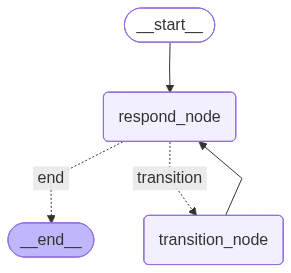

In [12]:
display(
    Image(
        agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

Now we invoke the agent through all three phases. The user's initial request goes in under chat mode. The agent responds, the router detects a next phase, and the cycle runs through research → planning, each with a full handoff. Watch the node print output to see the state-management decisions being made in real time.

In [13]:
# Initial state: user starts a conversation in chat mode
initial_state: AgentState = {
    "messages": [
        HumanMessage(
            content=(
                "I want to build a production RAG pipeline for our customer support team. "
                "Can you help me understand the key architectural decisions I need to make?"
            )
        )
    ],
    "current_mode": "chat",
    "mode_history": ["chat"],
    "task_goal": "Build a production RAG pipeline for customer support",
    "completed_steps": [],
    "human_decisions": ["Approved: self-hosted deployment", "Approved: OpenAI embeddings"],
    "current_draft": "",
    "transition_log": [],
}

print("RUNNING MULTI-PHASE WORKFLOW: chat → research → planning")
print("=" * 65)
print()

final_state = agent.invoke(initial_state)

RUNNING MULTI-PHASE WORKFLOW: chat → research → planning

  [respond] Mode: CHAT
    Response preview: Absolutely! Building a production RAG (Retrieval-Augmented Generation) pipeline for customer support is an exciting project. Here are some key archite...
  [router] mode=CHAT → TRANSITION
  [transition] CHAT → RESEARCH
    History preserved : True
    Steps carried     : 0
    Draft carried     : False
  [respond] Mode: RESEARCH
    Response preview: ### Building a Production RAG Pipeline for Customer Support

#### Overview
Given the decisions made for a self-hosted deployment and the use of OpenAI...
  [router] mode=RESEARCH → TRANSITION
  [transition] RESEARCH → PLANNING
    History preserved : True
    Steps carried     : 0
    Draft carried     : True
  [respond] Mode: PLANNING
    Response preview: ### Building a Production RAG Pipeline for Customer Support

#### Overview
Given the decisions made for a self-hosted deployment and the use of OpenAI...
  [router] mode=PLANNING → END

Each node prints its activity as the graph runs, giving us a live view of the state management decisions. Now let's inspect the results.

In [14]:
print("\nFINAL SESSION STATE")
print("=" * 65)
print(f"Final mode     : {final_state['current_mode'].upper()}")
print(f"Mode history   : {' → '.join(m.upper() for m in final_state['mode_history'])}")
print(f"Completed steps: {len(final_state['completed_steps'])}")
print(f"Transitions    : {len(final_state['transition_log'])}")
print()

print("TRANSITION AUDIT LOG")
print("-" * 65)
for i, entry in enumerate(final_state["transition_log"], start=1):
    print(f"[{i}] {entry['from_mode'].upper()} → {entry['to_mode'].upper()} at {entry['timestamp']}")
    print(f"     History preserved : {entry['history_preserved']}")
    print(f"     Steps carried     : {entry['steps_carried']}")
    print(f"     Decisions carried : {entry['decisions_carried']}")
print()

print("FINAL PLANNING MODE RESPONSE (last AI message)")
print("-" * 65)
for msg in reversed(final_state["messages"]):
    if msg.type == "ai":
        print(msg.content[:800] + ("..." if len(msg.content) > 800 else ""))
        break


FINAL SESSION STATE
Final mode     : PLANNING
Mode history   : CHAT → RESEARCH → PLANNING
Completed steps: 0
Transitions    : 2

TRANSITION AUDIT LOG
-----------------------------------------------------------------
[1] CHAT → RESEARCH at 2026-06-05T19:16:28+00:00
     History preserved : True
     Steps carried     : 0
     Decisions carried : 2
[2] RESEARCH → PLANNING at 2026-06-05T19:16:42+00:00
     History preserved : True
     Steps carried     : 0
     Decisions carried : 2

FINAL PLANNING MODE RESPONSE (last AI message)
-----------------------------------------------------------------
### Building a Production RAG Pipeline for Customer Support

#### Overview
Given the decisions made for a self-hosted deployment and the use of OpenAI embeddings, the next steps involve detailed planning and implementation of the RAG pipeline components. Below, I outline the necessary components and actionable steps to build the pipeline.

---

### Actionable Steps for Building the RAG Pipeline



## Audit logging
Every mode transition must leave a trace. In a production system, the audit log is how you answer the question "why did the agent switch modes, and what did it carry across?" without replaying the entire session or reading conversation content.

The key principle is to log **metadata, not content**: record how many messages were preserved, not the messages themselves. This keeps entries compact and avoids writing potentially sensitive dialogue to a secondary logging system. The `log_mode_transition()` function below is a standalone utility that makes this pattern explicit - the `transition_mode()` function incorporates equivalent logic internally, but showing it here clarifies the structure.

In [16]:
def log_mode_transition(
    from_mode: str,
    to_mode: str,
    reason: str,
    preserved_state: dict,
    session_id: str,
) -> dict:
    """Create an audit log entry for a mode transition.

    Logs metadata only — never the full content of messages or drafts.
    This keeps the log compact and avoids storing sensitive content in a secondary system.

    Args:
        from_mode: The mode being exited.
        to_mode: The mode being entered.
        reason: The reason for the transition.
        preserved_state: The state package from ModeTransitionManager.transition().
        session_id: The session identifier.

    Returns:
        An audit log entry dict.
    """
    entry = {
        "event": "mode_transition",
        "session_id": session_id,
        "timestamp": get_current_timestamp(),
        "from_mode": from_mode,
        "to_mode": to_mode,
        "reason": reason,
        "state_metadata": {
            # Counts only — never raw content
            "conversation_turns_preserved": len(
                preserved_state.get("conversation_history", [])
            ),
            "completed_steps_count": len(
                preserved_state.get("completed_steps", [])
            ),
            "human_decisions_count": len(
                preserved_state.get("human_decisions", [])
            ),
            "draft_preserved": bool(preserved_state.get("current_draft", "")),
            "tool_results_keys": list(
                preserved_state.get("tool_results", {}).keys()
            ),
        },
    }
    return entry


# Generate the audit log entry from our example transition
audit_entry = log_mode_transition(
    from_mode="research",
    to_mode="planning",
    reason="task_continuation",
    preserved_state=example_state,
    session_id="session-demo-001",
)

print("AUDIT LOG ENTRY")
print(json.dumps(audit_entry, indent=2))

# Show the full audit log from the LangGraph demo
print("\nAUDIT LOG FROM LANGGRAPH DEMO")
print(json.dumps(final_state["transition_log"], indent=2))

AUDIT LOG ENTRY
{
  "event": "mode_transition",
  "session_id": "session-demo-001",
  "timestamp": "2026-06-05T19:17:01+00:00",
  "from_mode": "research",
  "to_mode": "planning",
  "reason": "task_continuation",
  "state_metadata": {
    "conversation_turns_preserved": 0,
    "completed_steps_count": 4,
    "human_decisions_count": 2,
    "draft_preserved": true,
    "tool_results_keys": []
  }
}

AUDIT LOG FROM LANGGRAPH DEMO
[
  {
    "event": "mode_transition",
    "session_id": "session-001",
    "timestamp": "2026-06-05T19:16:28+00:00",
    "from_mode": "chat",
    "to_mode": "research",
    "reason": "task_continuation",
    "history_preserved": true,
    "steps_carried": 0,
    "decisions_carried": 2,
    "draft_carried": false
  },
  {
    "event": "mode_transition",
    "session_id": "session-001",
    "timestamp": "2026-06-05T19:16:42+00:00",
    "from_mode": "research",
    "to_mode": "planning",
    "reason": "task_continuation",
    "history_preserved": true,
    "steps_c

The audit log entry tells us everything we need for debugging and compliance without exposing conversation content: when the transition happened, why, what the mode history was, and what categories of state were preserved. In a production system this entry would be written to a structured logging backend (e.g. CloudWatch, Datadog, or a purpose-built audit database).